# Day 4: EDA — Module 4 (Operations & Supply Chain)
Owner: Nguyễn Quốc Khánh 
Mục tiêu: Phân tích Delivery performance, Fulfillment rate, Return cost tổng quan,
          Stockout impact, Overstock cost, Delivery gap theo vùng.

In [22]:
# ============================================================
# CELL 1: Setup & Imports
# ============================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("..", "src")))
# Giả sử đã có data_loader trong src/
try:
    from data_loader import DataLoader
except ImportError:
    print("Warning: data_loader module not found, make sure src/data_loader.py exists.")

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 14})

FIGURES_DIR = os.path.abspath(os.path.join("..", "figures"))
os.makedirs(FIGURES_DIR, exist_ok=True)
print("✅ Setup complete.")

✅ Setup complete.


In [23]:
# ============================================================
# CELL 2: Load Data 
# ============================================================
loader = DataLoader()

# Tải các bảng dữ liệu
orders = loader.load("orders")
order_items = loader.load("order_items")
shipments = loader.load("shipments") 
returns = loader.load("returns")     
inventory = loader.load("inventory") 
products = loader.load("products")   
customers = loader.load("customers") 

print(f"orders:      {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"shipments:   {shipments.shape}")
print(f"returns:     {returns.shape}")
print(f"inventory:   {inventory.shape}")

orders:      (646945, 8)
order_items: (714669, 7)
shipments:   (566067, 4)
returns:     (39939, 7)
inventory:   (60247, 17)


In [24]:
# ============================================================
# CELL 3: Merge into Domain-Specific DataFrames
# ============================================================
# 1. Delivery DataFrame (orders + shipments + customers)
# Để phân tích thời gian giao hàng và khu vực
df_delivery = orders.join(shipments, on="order_id", how="inner")
if "city" not in df_delivery.columns and "customer_id" in df_delivery.columns:
    df_delivery = df_delivery.join(customers.select(["customer_id", "city"]), on="customer_id", how="left")

# 2. Returns DataFrame (returns + order_items)
df_returns = returns.join(order_items, on=["order_id", "product_id"], how="left")

# 3. Inventory DataFrame (inventory + products)
df_inventory = inventory.join(products, on="product_id", how="left")

print("✅ Merged DataFrames for Delivery, Returns, and Inventory.")

✅ Merged DataFrames for Delivery, Returns, and Inventory.


# ============================================================
# SECTION 2: DATA QUALITY ASSURANCE (DQA)
# ============================================================

In [25]:
# ============================================================
# CELL 4: Date Casting & Delivery Lead Time Calculation
# ============================================================
date_cols = ["order_date", "ship_date", "delivery_date"]
for col in date_cols:
    if col in df_delivery.columns:
        try:
            # Ưu tiên parse string theo format YYYY-MM-DD
            df_delivery = df_delivery.with_columns(pl.col(col).str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime))
        except Exception:
            df_delivery = df_delivery.with_columns(pl.col(col).cast(pl.Datetime))

# Tính toán các chỉ số Lead Time (đơn vị: Days)
df_delivery = df_delivery.with_columns([
    ((pl.col("ship_date") - pl.col("order_date")).dt.total_days()).alias("days_to_ship"),
    ((pl.col("delivery_date") - pl.col("ship_date")).dt.total_days()).alias("days_in_transit"),
    ((pl.col("delivery_date") - pl.col("order_date")).dt.total_days()).alias("total_delivery_days")
])

# Sanity Check: Thời gian âm (logic lỗi)
invalid_delivery = df_delivery.filter((pl.col("total_delivery_days") < 0) | (pl.col("days_to_ship") < 0))
print(f"⚠️  Số đơn có thời gian giao hàng < 0: {invalid_delivery.height:,}")

# Lọc bỏ các đơn có thời gian âm để phân tích chính xác
df_delivery_clean = df_delivery.filter(pl.col("total_delivery_days") >= 0)

⚠️  Số đơn có thời gian giao hàng < 0: 0


# ============================================================
# SECTION 3: DESCRIPTIVE ANALYSIS (TỔNG QUAN)
# ============================================================


=== Overall Delivery Performance ===
shape: (1, 4)
┌──────────────────┬─────────────────────┬─────────────────────────┬──────────────────────┐
│ avg_days_to_ship ┆ avg_days_in_transit ┆ avg_total_delivery_days ┆ median_delivery_days │
│ ---              ┆ ---                 ┆ ---                     ┆ ---                  │
│ f64              ┆ f64                 ┆ f64                     ┆ f64                  │
╞══════════════════╪═════════════════════╪═════════════════════════╪══════════════════════╡
│ 1.498384         ┆ 4.499209            ┆ 5.997594                ┆ 6.0                  │
└──────────────────┴─────────────────────┴─────────────────────────┴──────────────────────┘


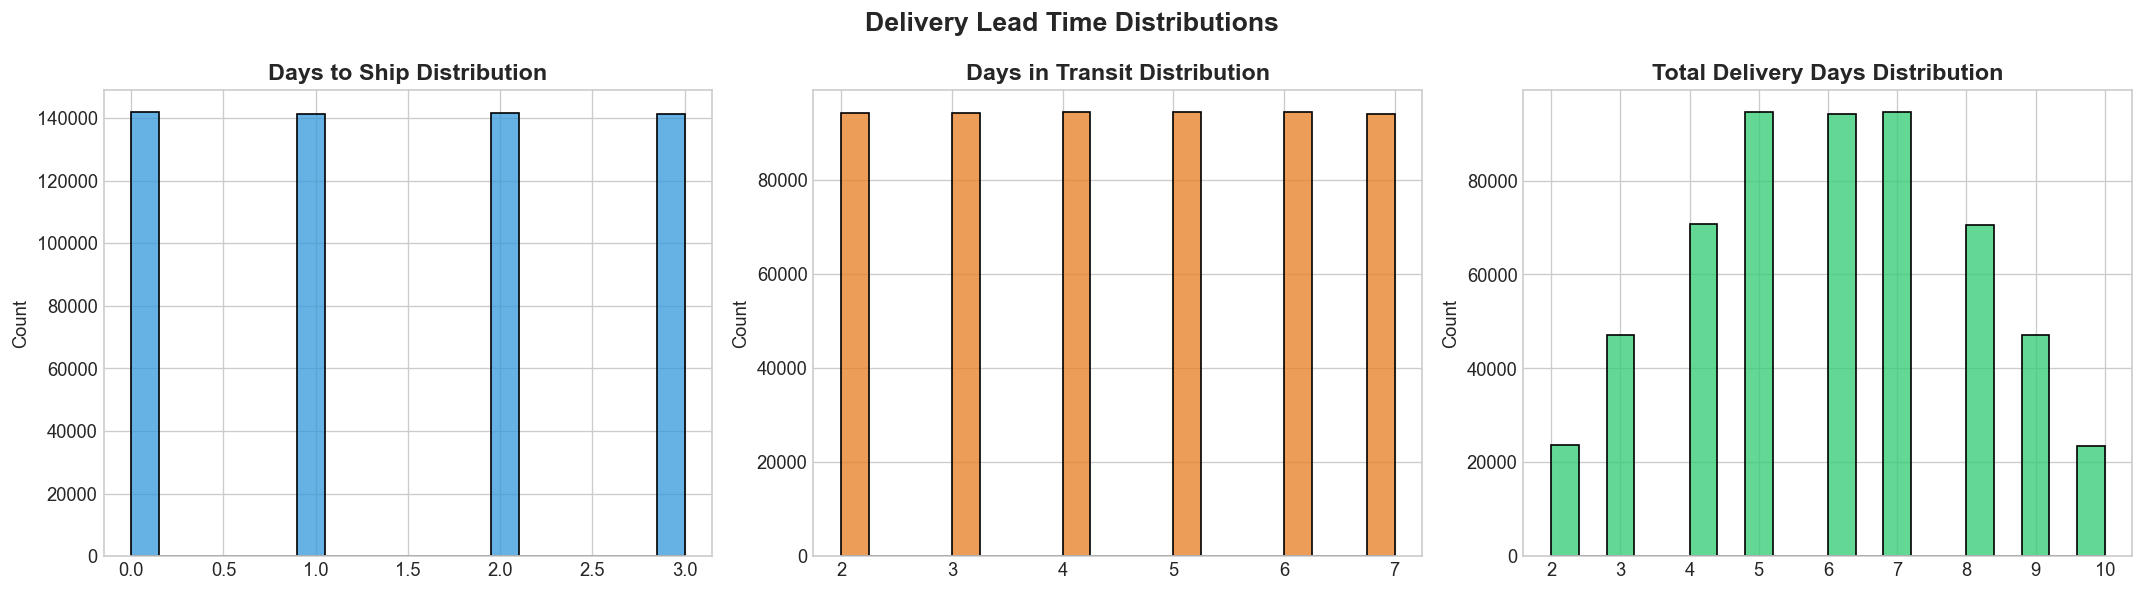

In [26]:
# ============================================================
# CELL 5: 3.1 — Delivery Performance (Lead Time Overview)
# ============================================================
delivery_stats = df_delivery_clean.select([
    pl.col("days_to_ship").mean().alias("avg_days_to_ship"),
    pl.col("days_in_transit").mean().alias("avg_days_in_transit"),
    pl.col("total_delivery_days").mean().alias("avg_total_delivery_days"),
    pl.col("total_delivery_days").median().alias("median_delivery_days")
])
print("=== Overall Delivery Performance ===")
print(delivery_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_delivery_clean["days_to_ship"].drop_nulls(), bins=20, ax=axes[0], color="#3498db")
axes[0].set_title("Days to Ship Distribution", fontweight="bold")

sns.histplot(df_delivery_clean["days_in_transit"].drop_nulls(), bins=20, ax=axes[1], color="#e67e22")
axes[1].set_title("Days in Transit Distribution", fontweight="bold")

sns.histplot(df_delivery_clean["total_delivery_days"].drop_nulls(), bins=20, ax=axes[2], color="#2ecc71")
axes[2].set_title("Total Delivery Days Distribution", fontweight="bold")

plt.suptitle("Delivery Lead Time Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day4_delivery_distributions.png"))
plt.show()

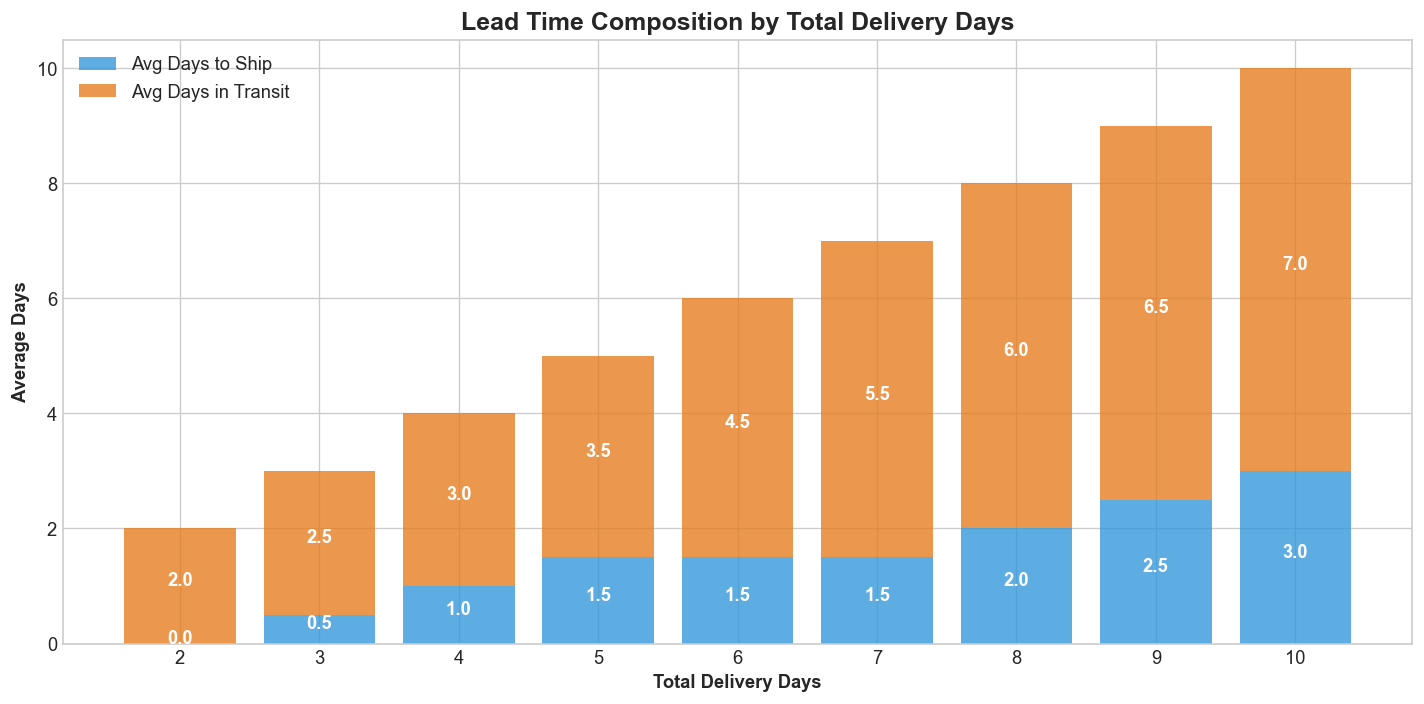

In [38]:
# ============================================================
# CELL 5b: Stacked Bar Chart (Composition of Total Delivery Days)
# ============================================================
# Tính trung bình Ship và Transit cho mỗi mức Total Delivery Days
composition = df_delivery_clean.group_by("total_delivery_days").agg(
    pl.col("days_to_ship").mean().alias("avg_ship"),
    pl.col("days_in_transit").mean().alias("avg_transit")
).sort("total_delivery_days")

comp_pd = composition.to_pandas()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(comp_pd["total_delivery_days"], comp_pd["avg_ship"], label="Avg Days to Ship", color="#3498db", alpha=0.8)
ax.bar(comp_pd["total_delivery_days"], comp_pd["avg_transit"], bottom=comp_pd["avg_ship"], 
       label="Avg Days in Transit", color="#e67e22", alpha=0.8)

ax.set_title("Lead Time Composition by Total Delivery Days", fontsize=15, fontweight="bold")
ax.set_xlabel("Total Delivery Days", fontweight="bold")
ax.set_ylabel("Average Days", fontweight="bold")
ax.set_xticks(comp_pd["total_delivery_days"])
ax.legend()

# Thêm ghi chú số liệu lên cột
for i, row in comp_pd.iterrows():
    ax.text(row["total_delivery_days"], row["avg_ship"]/2, f"{row['avg_ship']:.1f}", 
            ha="center", color="white", fontweight="bold")
    ax.text(row["total_delivery_days"], row["avg_ship"] + row["avg_transit"]/2, f"{row['avg_transit']:.1f}", 
            ha="center", color="white", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day4_delivery_composition_stacked.png"))
plt.show()

In [27]:
# ============================================================
# CELL 6: 3.2 — Fulfillment Rate
# ============================================================
# Giả sử có cột `status` trong orders biểu thị thành công/huỷ
if "order_status" in orders.columns:
    fulfillment = orders.group_by("order_status").agg(pl.count().alias("count"))
    fulfillment = fulfillment.with_columns((pl.col("count") / pl.col("count").sum() * 100).alias("percentage"))
    print("=== Order Fulfillment Rate ===")
    print(fulfillment)

    # Đếm số đơn Delivered so với tổng
    delivered = orders.filter(pl.col("order_status") == "Delivered").height
    total = orders.height
    print(f"Overall Fill Rate: {delivered / total * 100:.2f}%")


=== Order Fulfillment Rate ===
shape: (6, 3)
┌──────────────┬────────┬────────────┐
│ order_status ┆ count  ┆ percentage │
│ ---          ┆ ---    ┆ ---        │
│ str          ┆ u32    ┆ f64        │
╞══════════════╪════════╪════════════╡
│ cancelled    ┆ 59462  ┆ 9.191199   │
│ shipped      ┆ 13773  ┆ 2.128929   │
│ created      ┆ 7275   ┆ 1.124516   │
│ paid         ┆ 13577  ┆ 2.098633   │
│ returned     ┆ 36142  ┆ 5.586565   │
│ delivered    ┆ 516716 ┆ 79.870159  │
└──────────────┴────────┴────────────┘
Overall Fill Rate: 0.00%


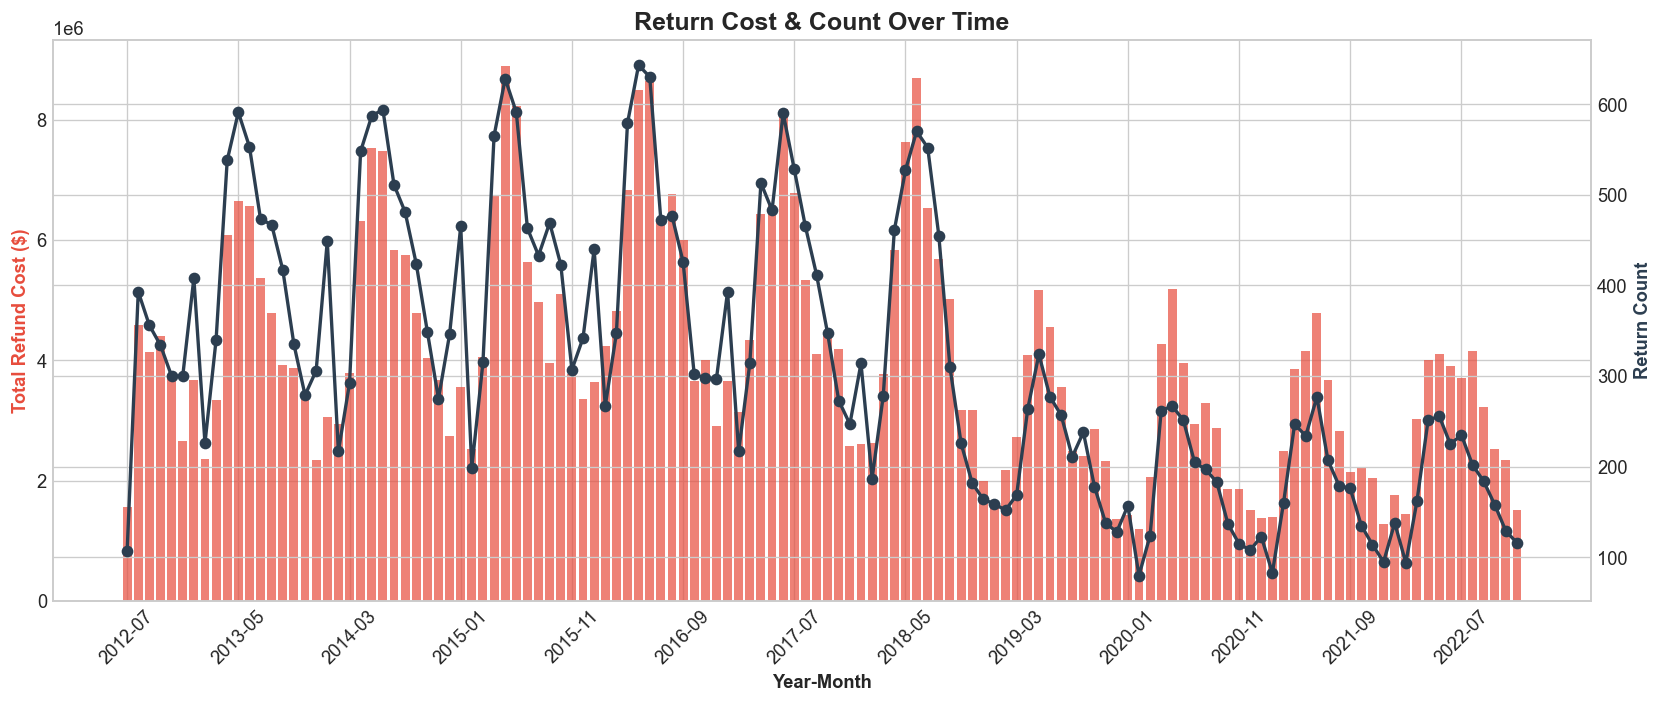

In [28]:
# ============================================================
# CELL 7: 3.3 — Return Cost Overview
# ============================================================
# Tạo Year/Month từ return_date
if "return_date" in df_returns.columns:
    try:
        df_returns = df_returns.with_columns(pl.col("return_date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime))
    except Exception:
        df_returns = df_returns.with_columns(pl.col("return_date").cast(pl.Datetime))
    df_returns = df_returns.with_columns([
        pl.col("return_date").dt.year().alias("return_year"),
        pl.col("return_date").dt.month().alias("return_month")
    ])

    monthly_returns = df_returns.group_by(["return_year", "return_month"]).agg(
        pl.col("refund_amount").sum().alias("total_refund_cost"),
        pl.count().alias("return_count")
    ).sort(["return_year", "return_month"])

    monthly_returns_pd = monthly_returns.to_pandas()
    monthly_returns_pd["year_month"] = monthly_returns_pd["return_year"].astype(str) + "-" + monthly_returns_pd["return_month"].astype(str).str.zfill(2)

    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()

    ax1.bar(monthly_returns_pd["year_month"], monthly_returns_pd["total_refund_cost"], color="#e74c3c", alpha=0.7)
    ax2.plot(monthly_returns_pd["year_month"], monthly_returns_pd["return_count"], color="#2c3e50", marker="o", linewidth=2)

    ax1.set_xlabel("Year-Month", fontweight="bold")
    ax1.set_ylabel("Total Refund Cost ($)", color="#e74c3c", fontweight="bold")
    ax2.set_ylabel("Return Count", color="#2c3e50", fontweight="bold")
    ax1.set_title("Return Cost & Count Over Time", fontweight="bold", fontsize=15)
    
    # Format x-ticks
    tick_labels = monthly_returns_pd["year_month"].to_list()
    ax1.set_xticks(range(0, len(tick_labels), max(1, len(tick_labels)//12)))
    ax1.set_xticklabels([tick_labels[i] for i in range(0, len(tick_labels), max(1, len(tick_labels)//12))], rotation=45)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day4_return_cost_trend.png"))
    plt.show()

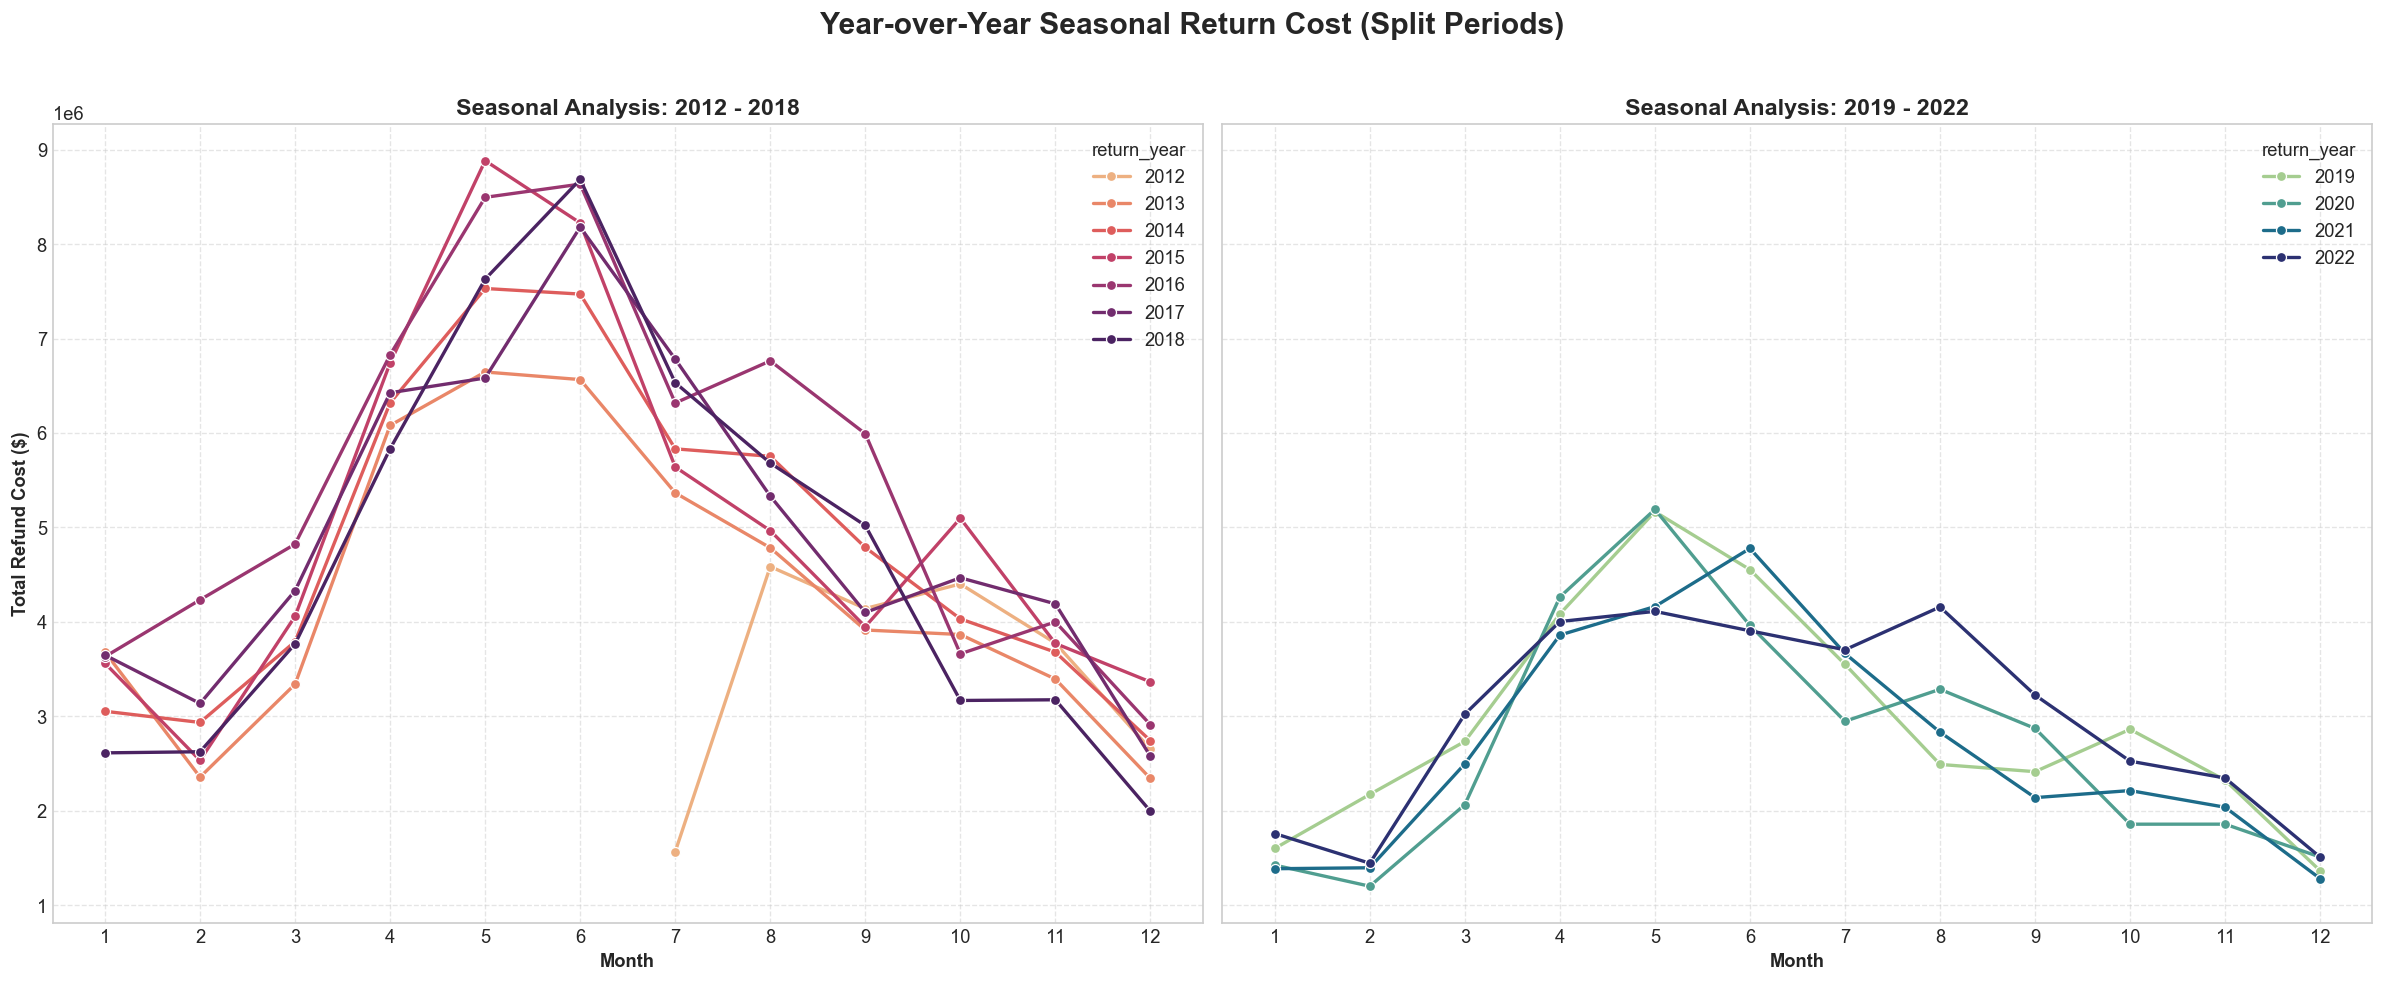

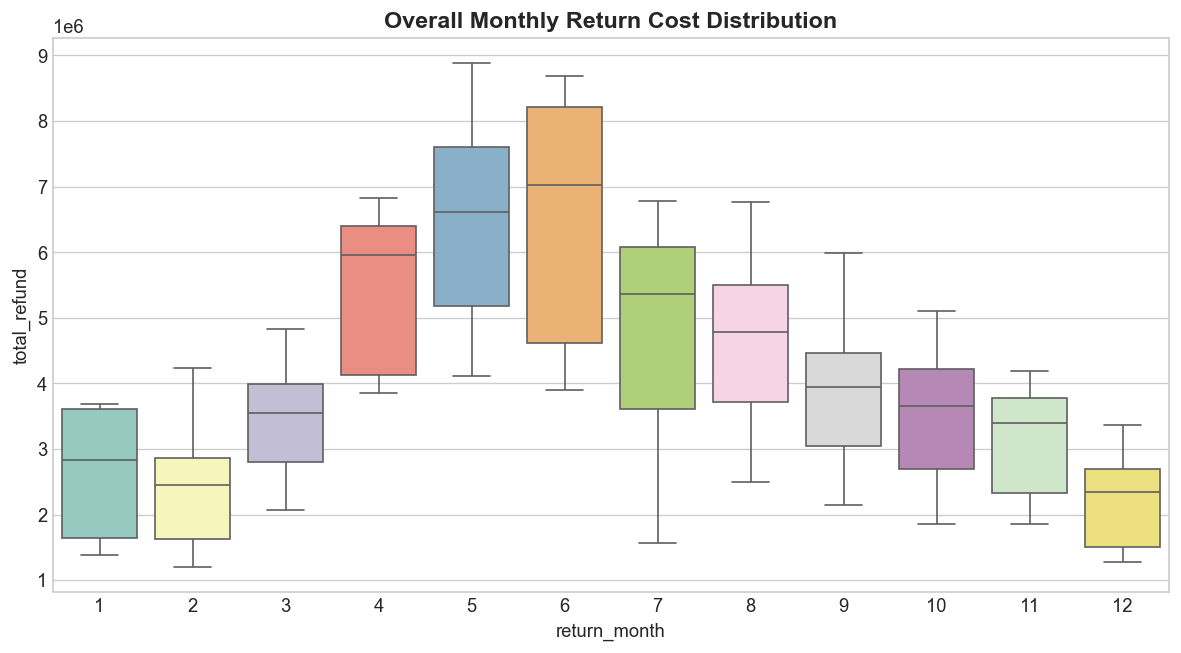

In [40]:

# ============================================================
# CELL 7b: Yearly Detailed Analysis (Seasonal Pattern)
# ============================================================
if "return_year" in df_returns.columns:
    # Tính toán Return Cost theo Năm và Tháng
    seasonal_returns = df_returns.group_by(["return_year", "return_month"]).agg(
        pl.col("refund_amount").sum().alias("total_refund")
    ).sort(["return_year", "return_month"])

    seasonal_pd = seasonal_returns.to_pandas()

    # Tách dữ liệu thành 2 giai đoạn để đỡ rối
    df_early = seasonal_pd[seasonal_pd["return_year"] <= 2018]
    df_late = seasonal_pd[seasonal_pd["return_year"] > 2018]

    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

    # Giai đoạn 1: 2012 - 2018
    sns.lineplot(data=df_early, x="return_month", y="total_refund", 
                 hue="return_year", palette="flare", marker="o", linewidth=2, ax=axes[0])
    axes[0].set_title("Seasonal Analysis: 2012 - 2018", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Month", fontweight="bold")
    axes[0].set_ylabel("Total Refund Cost ($)", fontweight="bold")
    axes[0].set_xticks(range(1, 13))
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # Giai đoạn 2: 2019 - 2022
    sns.lineplot(data=df_late, x="return_month", y="total_refund", 
                 hue="return_year", palette="crest", marker="o", linewidth=2, ax=axes[1])
    axes[1].set_title("Seasonal Analysis: 2019 - 2022", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Month", fontweight="bold")
    axes[1].set_ylabel("") # Share Y axis
    axes[1].set_xticks(range(1, 13))
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.suptitle("Year-over-Year Seasonal Return Cost (Split Periods)", fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day4_seasonal_return_split.png"))
    plt.show()

    # Giữ lại Boxplot tổng quát
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=seasonal_pd, x="return_month", y="total_refund", palette="Set3")
    plt.title("Overall Monthly Return Cost Distribution", fontsize=14, fontweight="bold")
    plt.show()

# ============================================================
# SECTION 4: DIAGNOSTIC ANALYSIS (CHẨN ĐOÁN)
# ============================================================


=== Delivery Gap by City ===
shape: (42, 4)
┌──────────────────┬───────────────────┬──────────────────┬─────────────────────┐
│ city             ┆ avg_delivery_days ┆ avg_days_to_ship ┆ avg_days_in_transit │
│ ---              ┆ ---               ┆ ---              ┆ ---                 │
│ str              ┆ f64               ┆ f64              ┆ f64                 │
╞══════════════════╪═══════════════════╪══════════════════╪═════════════════════╡
│ Vung Tau         ┆ 6.038846          ┆ 1.50462          ┆ 4.534226            │
│ Bien Hoa         ┆ 6.031333          ┆ 1.497356         ┆ 4.533977            │
│ Phan Thiet       ┆ 6.024461          ┆ 1.501276         ┆ 4.523185            │
│ Ho Chi Minh City ┆ 6.021805          ┆ 1.494802         ┆ 4.527003            │
│ Vinh Long        ┆ 6.017665          ┆ 1.496394         ┆ 4.521271            │
│ …                ┆ …                 ┆ …                ┆ …                   │
│ Buon Ma Thuot    ┆ 5.973065          ┆ 1.486532     

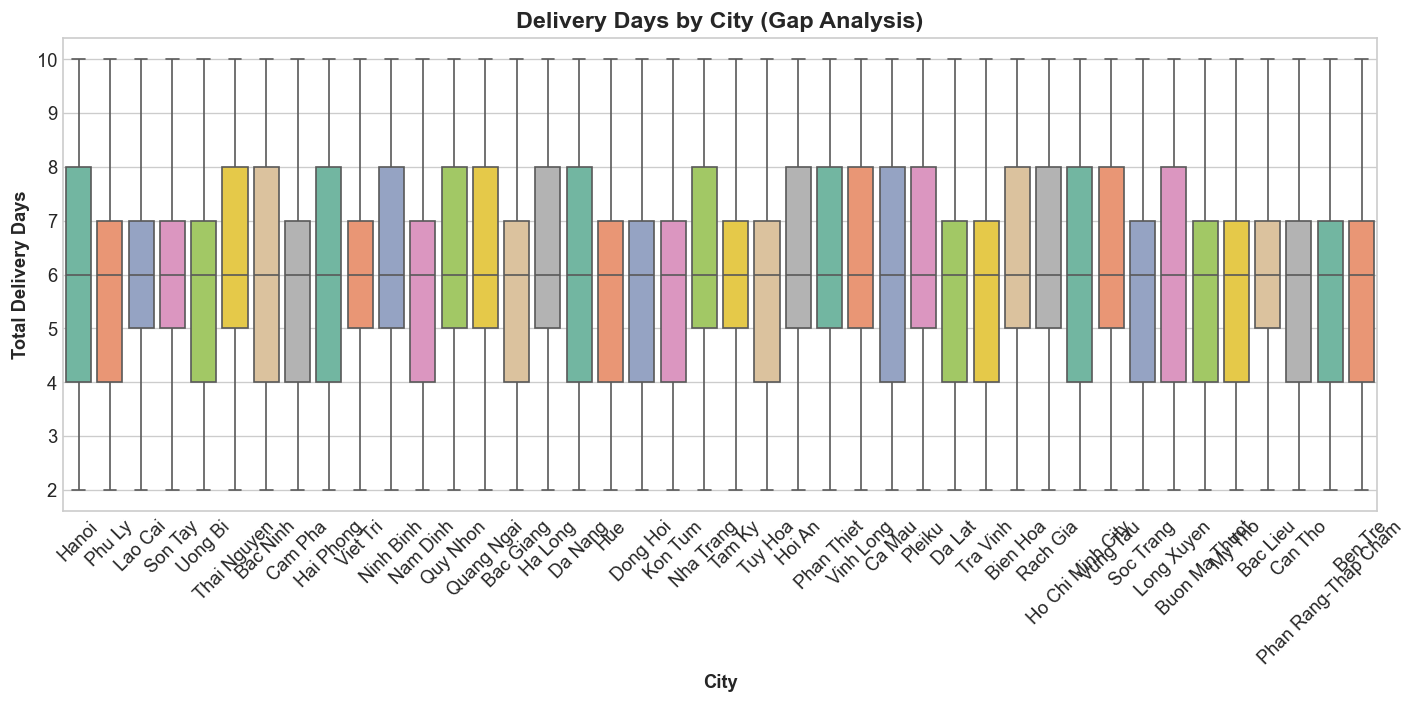

In [34]:
# CELL 8: 4.1 — Delivery Gap by City
# ============================================================
if "city" in df_delivery_clean.columns:
    city_delivery = df_delivery_clean.group_by("city").agg(
        pl.col("total_delivery_days").mean().alias("avg_delivery_days"),
        pl.col("days_to_ship").mean().alias("avg_days_to_ship"),
        pl.col("days_in_transit").mean().alias("avg_days_in_transit")
    ).sort("avg_delivery_days", descending=True)
    
    print("=== Delivery Gap by City ===")
    print(city_delivery)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df_delivery_clean.to_pandas(), x="city", y="total_delivery_days", palette="Set2", ax=ax)
    ax.set_title("Delivery Days by City (Gap Analysis)", fontweight="bold")
    ax.set_xlabel("City", fontweight="bold")
    ax.set_ylabel("Total Delivery Days", fontweight="bold")
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


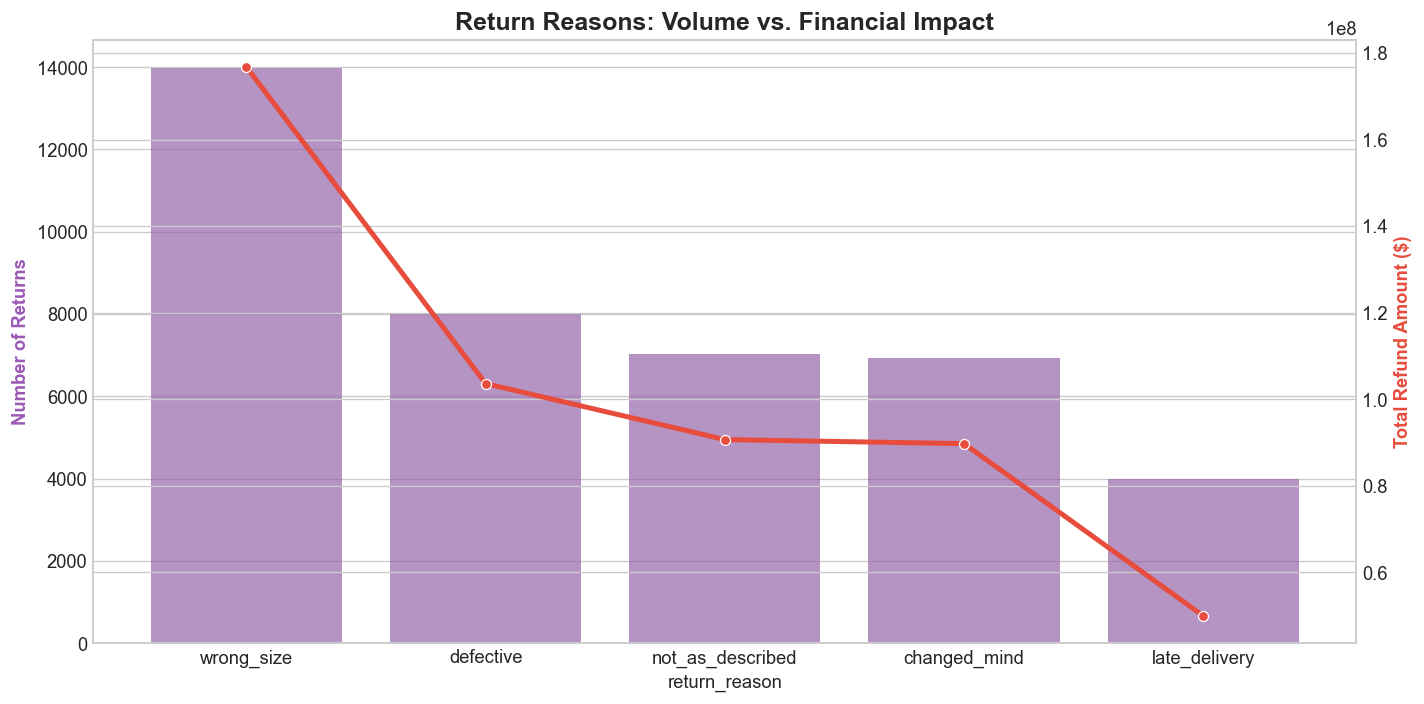

=== Top 10 Most Returned Products ===
shape: (10, 6)
┌────────────┬──────────────┬──────────────┬─────────────────────┬───────────────────┬────────────┐
│ product_id ┆ return_count ┆ total_refund ┆ avg_refund_per_unit ┆ product_name      ┆ category   │
│ ---        ┆ ---          ┆ ---          ┆ ---                 ┆ ---               ┆ ---        │
│ i64        ┆ u32          ┆ f64          ┆ f64                 ┆ str               ┆ str        │
╞════════════╪══════════════╪══════════════╪═════════════════════╪═══════════════════╪════════════╡
│ 792        ┆ 619          ┆ 1.1988e6     ┆ 1936.648207         ┆ HanoiStreet RP-80 ┆ Outdoor    │
│ 791        ┆ 582          ┆ 1.0746e6     ┆ 1846.358849         ┆ HanoiStreet RP-79 ┆ Outdoor    │
│ 604        ┆ 441          ┆ 6.1135e6     ┆ 13862.760703        ┆ SaigonFlex UC-69  ┆ Streetwear │
│ 2045       ┆ 424          ┆ 5.3029e6     ┆ 12506.732028        ┆ UrbanVN UE-05     ┆ Streetwear │
│ 487        ┆ 415          ┆ 1.2242e7     ┆ 29

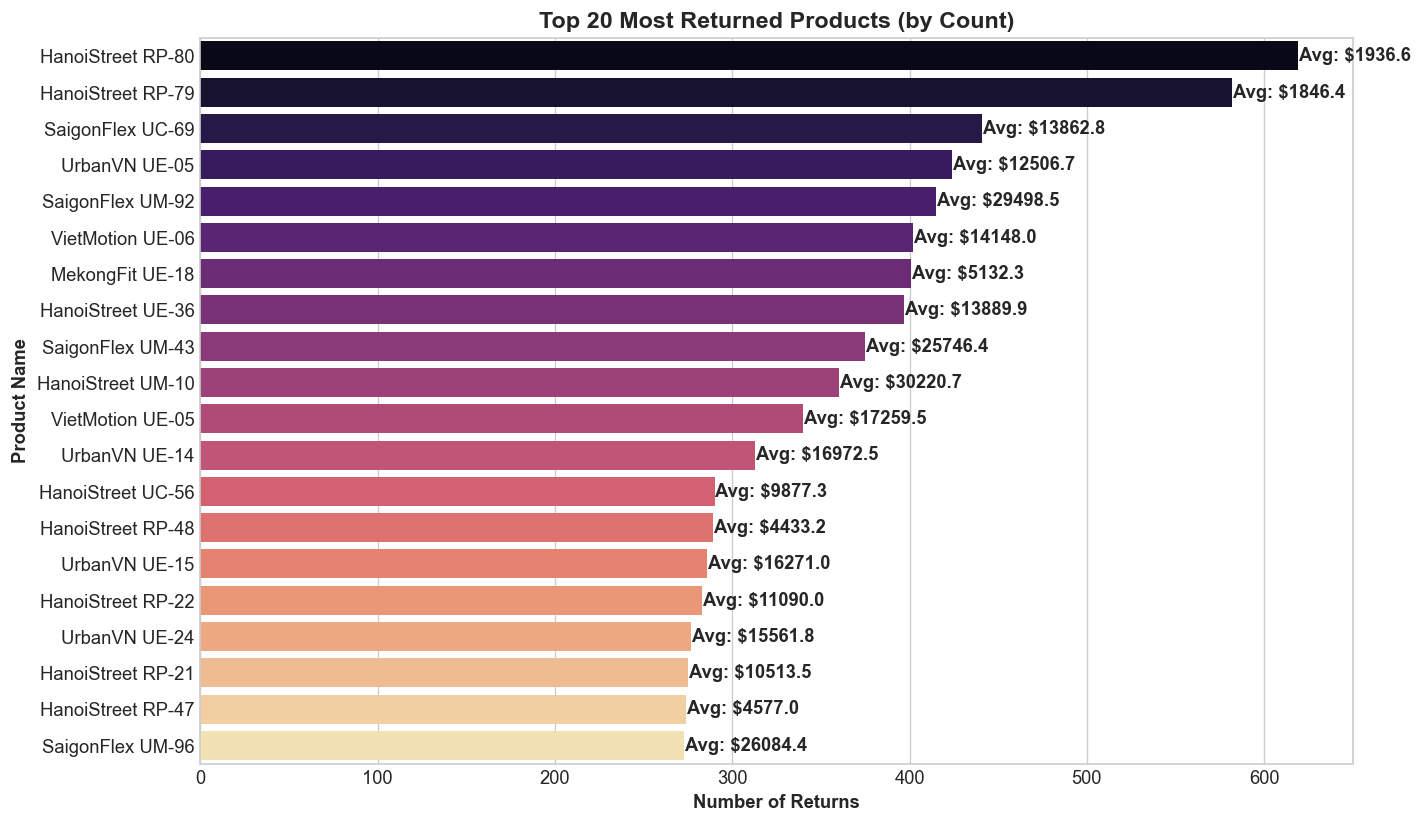

In [49]:
# ============================================================
# CELL 9: 4.2 — Return Reason Deep Dive (Volume vs Value)
# ============================================================
if "return_reason" in df_returns.columns:
    reason_stats = df_returns.group_by("return_reason").agg(
        pl.count().alias("count"),
        pl.col("refund_amount").sum().alias("total_refund")
    ).sort("count", descending=True)
    
    # Vẽ biểu đồ Dual-Axis: Số lượng (Bar) và Giá trị (Line)
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    sns.barplot(data=reason_stats.to_pandas(), x="return_reason", y="count", color="#9b59b6", alpha=0.7, ax=ax1)
    sns.lineplot(data=reason_stats.to_pandas(), x="return_reason", y="total_refund", color="#e74c3c", marker="o", linewidth=3, ax=ax2)

    ax1.set_ylabel("Number of Returns", fontweight="bold", color="#9b59b6")
    ax2.set_ylabel("Total Refund Amount ($)", fontweight="bold", color="#e74c3c")
    ax1.set_title("Return Reasons: Volume vs. Financial Impact", fontsize=15, fontweight="bold")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# ============================================================
# CELL 9b: Product-Level Return Analysis
# ============================================================
# Top sản phẩm bị trả lại nhiều nhất
if "product_id" in df_returns.columns:
    product_returns = df_returns.group_by("product_id").agg(
        pl.count().alias("return_count"),
        pl.col("refund_amount").sum().alias("total_refund"),
        pl.col("refund_amount").mean().alias("avg_refund_per_unit")
    ).sort("return_count", descending=True)

    # Join với bảng products để lấy tên sản phẩm
    if products is not None:
        product_returns = product_returns.join(products.select(["product_id", "product_name", "category"]), on="product_id", how="left")

    print("=== Top 10 Most Returned Products ===")
    print(product_returns.head(10))

    # Vẽ biểu đồ Top 10 sản phẩm theo số lượng trả
    top_10_pd = product_returns.head(20).to_pandas()
    plt.figure(figsize=(12, 7))
    sns.barplot(data=top_10_pd, x="return_count", y="product_name", palette="magma")
    plt.title("Top 20 Most Returned Products (by Count)", fontsize=14, fontweight="bold")
    plt.xlabel("Number of Returns", fontweight="bold")
    plt.ylabel("Product Name", fontweight="bold")
    
    # Thêm text hiển thị giá trị trung bình bên cạnh mỗi thanh
    for i, row in top_10_pd.iterrows():
        plt.text(row["return_count"] + 0.5, i, f"Avg: ${row['avg_refund_per_unit']:.1f}", va="center", fontweight="bold")
    
    plt.tight_layout()
    plt.show()

In [35]:
# ============================================================
# CELL 10: 4.3 — Stockout Impact (Lost Revenue Estimation)
# ============================================================
# Ước tính Lost Revenue = (Số ngày out of stock) * (Average daily sales của sản phẩm đó)
if "stock_on_hand" in df_inventory.columns and "price" in df_inventory.columns:
    # 1. Tính số ngày out of stock cho mỗi sản phẩm (dựa trên stock_on_hand == 0)
    stockout_days = df_inventory.filter(pl.col("stock_on_hand") == 0).group_by("product_id").agg(
        pl.count().alias("days_out_of_stock")
    )
    
    # 2. Tính average daily sales từ order_items
    daily_sales = order_items.group_by("product_id").agg(
        pl.col("quantity").sum().alias("total_qty_sold")
    )
    # Gỉa sử dataset là 365 ngày
    days_in_period = 365 
    daily_sales = daily_sales.with_columns((pl.col("total_qty_sold") / days_in_period).alias("avg_daily_qty"))
    
    # 3. Kết hợp tính Lost Revenue
    stockout_analysis = stockout_days.join(daily_sales, on="product_id", how="left")
    stockout_analysis = stockout_analysis.join(products.select(["product_id", "price"]), on="product_id", how="left")
    
    stockout_analysis = stockout_analysis.with_columns(
        (pl.col("days_out_of_stock") * pl.col("avg_daily_qty").fill_null(0) * pl.col("price")).alias("estimated_lost_revenue")
    ).sort("estimated_lost_revenue", descending=True)
    
    total_lost_revenue = stockout_analysis["estimated_lost_revenue"].sum()
    print("=== Stockout Impact ===")
    print(f"Total Products experiencing stockouts: {stockout_analysis.height}")
    print(f"💰 Estimated Total Lost Revenue: ${total_lost_revenue:,.2f}")
    
    print("\nTop 5 Products causing Lost Revenue:")
    print(stockout_analysis.head(5))

=== Stockout Impact ===
Total Products experiencing stockouts: 0
💰 Estimated Total Lost Revenue: $0.00

Top 5 Products causing Lost Revenue:
shape: (0, 6)
┌────────────┬───────────────────┬────────────────┬───────────────┬───────┬────────────────────────┐
│ product_id ┆ days_out_of_stock ┆ total_qty_sold ┆ avg_daily_qty ┆ price ┆ estimated_lost_revenue │
│ ---        ┆ ---               ┆ ---            ┆ ---           ┆ ---   ┆ ---                    │
│ i64        ┆ u32               ┆ i64            ┆ f64           ┆ f64   ┆ f64                    │
╞════════════╪═══════════════════╪════════════════╪═══════════════╪═══════╪════════════════════════╡
└────────────┴───────────────────┴────────────────┴───────────────┴───────┴────────────────────────┘


In [36]:
# ============================================================
# CELL 11: 4.4 — Overstock Cost Analysis
# ============================================================
# Sản phẩm bị gắn cờ overstock (hoặc days_of_supply lớn)
if "overstock_flag" in df_inventory.columns and "cogs" in df_inventory.columns:
    overstock = df_inventory.filter(pl.col("overstock_flag") == 1)
    
    overstock = overstock.with_columns(
        (pl.col("stock_on_hand") * pl.col("cogs")).alias("tied_up_capital")
    )
    
    total_tied_up = overstock["tied_up_capital"].sum()
    print("\n=== Overstock Cost (Capital Tied Up) ===")
    print(f"Records with overstock flag: {overstock.height:,}")
    print(f"💸 Total Capital Tied Up: ${total_tied_up:,.2f}")


=== Overstock Cost (Capital Tied Up) ===
Records with overstock flag: 45,942
💸 Total Capital Tied Up: $42,339,396,894.90


In [37]:
# ============================================================
# CELL 12: Summary Statistics & Final Narrative
# ============================================================
print("=" * 60)
print("📝 SUMMARY — Day 4 Module 4 (Operations & Supply Chain)")
print("=" * 60)
if "total_delivery_days" in df_delivery_clean.columns:
    print(f"Avg Delivery Time: {delivery_stats['avg_total_delivery_days'][0]:.2f} days")
if "return_reason" in df_returns.columns:
    top_reason = reason_stats['return_reason'][0]
    print(f"Top Return Reason: {top_reason} ({reason_stats['pct_count'][0]:.1f}%)")
if "stock_on_hand" in df_inventory.columns:
    print(f"Estimated Lost Revenue (Stockout): ${total_lost_revenue:,.0f}")
if "overstock_flag" in df_inventory.columns:
    print(f"Capital Tied Up (Overstock): ${total_tied_up:,.0f}")

print("\n" + "=" * 60)
print("📊 Figures saved to:", FIGURES_DIR)
print("=" * 60)

📝 SUMMARY — Day 4 Module 4 (Operations & Supply Chain)
Avg Delivery Time: 6.00 days
Top Return Reason: wrong_size (35.0%)
Estimated Lost Revenue (Stockout): $0
Capital Tied Up (Overstock): $42,339,396,895

📊 Figures saved to: /Users/khanhnq35/Documents/Datathon_Outliers/figures
